# The Fourth Circle: Neural Networks, Part Two 
## Convolutional Neural Networks IX: Xception

<br/>
Jiří Fejlek

2026-04-29
<br/>


We continue our series on various convolutional network architectures by covering Xception [[1](#1)] from 2017. The Xception is inspired by the Inception architectures [[2](#2), [3](#3), [4](#4)], which introduced convolution block with multiple branches.  However, unlike Inception, in which these branches consisted of various convolution kernels, the convolution kernels used in Xception are all the same. This makes Xception very similar to ResNeXt [[5](#5)] from 2016, which we explored in the previous project. 

As we have discussed with the ResNeXt architecture, the result of making all branches in the inception block identical is a network that, instead of using a standard convolutional layer across all the input channels, groups the channels and applies a separate convolution layer to each group. Such a modified convolution layer is known as *grouped convolution* (or *separable convolution*). 

The main benefit of using grouped convolution layers instead of standard convolution is reducing the number of CNN parameters. The traditional convolutional layer with a kernel $k \times k$ with $n_\mathrm{in}$ input channels, $n_\mathrm{out}$ ouput channels has $k^2 n_\mathrm{in} n_\mathrm{out}$ parameters. When we move to a grouped convolution layer in which we group $n_\mathrm{in}$ input channels to $g$ groups, the number of parameters reduces to $\frac{k^2}{g}n_\mathrm{in}n_\mathrm{out}$. The reduction in the number of parameters is because each output channel is no longer computed from all input channels; instead, it is computed from input channels of a single group.


## Table of Contents

- [Xception](#xception)
    - [Grouped Convolution](#grouped_conv)
    - [Xception Architecture](#Xception_arch)
    - [Training Xception on Fashion-MNIST and CIFAR-10](#training)
- [References](#references)


## Xception <a class="anchor" id="xception"></a>

Again, we will first repeat the common functions used in these projects.

In [1]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

import torchvision
import torch

from torch import nn
from torch.utils.data import DataLoader

np.set_printoptions(legacy='1.25')

In [2]:
cuda_device = torch.device('cuda')
torch.cuda.get_device_name(cuda_device)

'NVIDIA GeForce RTX 4070 Ti'

In [3]:
def layer_summary(nn_model, X_shape):
    X = torch.randn(*X_shape)
    for layer in nn_model.net_stack:
        X = layer(X)
        print(layer.__class__.__name__, 'output shape:\t', X.shape)

In [4]:
def init_weights_he(model):
    if isinstance(model, nn.Linear):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0) 
    if isinstance(model, nn.Conv2d):
        nn.init.kaiming_normal_(model.weight, nonlinearity = 'relu') 
        nn.init.constant_(model.bias, 0)  

In [5]:
def train_test_loop_cuda(train_data_loader, test_data_loader, model, loss_fn, optimizer, scheduler):
    
    softmax = torch.nn.Softmax(dim = 1)
    model.train()

    loss_sum_train  = 0
    accu_sum_train = 0
    size_train = 0

    
    for batch, (X, y) in enumerate(train_data_loader):

        X = X.to(cuda_device)
        y = y.to(cuda_device)

        optimizer.zero_grad() # zero out the gradients
        
        pred_logits = model(X) # forward pass
        loss = loss_fn(pred_logits, y) # loss evaluation 

        # Backpropagation
        loss.backward() # gradient evaluation
        optimizer.step() # SGD step
        

        # compute prediction epoch loss and accuracy
        with torch.no_grad(): # we do not need to compute the gradients
            loss_sum_train = loss_sum_train + loss*len(X)
            size_train = size_train + len(X)
            accu_sum_train = accu_sum_train + ((softmax(pred_logits).argmax(dim = 1)-y).abs() == 0).long().sum()

    # evaluate performance on the test set
    with torch.no_grad(): 
        
        loss_sum_train = loss_sum_train/size_train
        accu_sum_train = accu_sum_train/size_train
        
        model.eval() 
        loss_sum_test  = 0
        accu_sum_test = 0
        size_test = 0
        
        for batch, (X_test, y_test) in enumerate(test_data_loader):

            X_test = X_test.to(cuda_device)
            y_test = y_test.to(cuda_device)
            
            pred_logits_test = model(X_test)
            loss_sum_test = loss_sum_test + loss_fn(pred_logits_test, y_test)*len(X_test)
            accu_sum_test = accu_sum_test + ((softmax(pred_logits_test).argmax(dim = 1)-y_test).abs() == 0).long().sum()
            size_test = size_test + len(X_test)

        loss_sum_test = loss_sum_test/size_test
        accu_sum_test = accu_sum_test/size_test
        
    # learning rate step; we use loss_sum_train for ReduceLROnPlateau
    learning_rate = scheduler.get_last_lr() 
    scheduler.step() 
    
    return  loss_sum_train.detach(), loss_sum_test.detach(), learning_rate[0], accu_sum_train.detach(), accu_sum_test.detach()

### Grouped Convolution <a class="anchor" id="grouped_conv"></a>

Let us discuss grouped convolution in more detail. We remind ourselves of the inception block [[2](#2)] to observe the similarity between it and a grouped convolution block [[1](#1)]. The architecture of the original inception block is as follows.

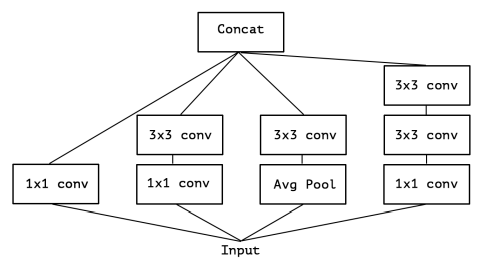

Let us now consider an inception block, in which various convolution blocks are replaced by a single one: a a 1x1 layer followed by 3x3 layer.

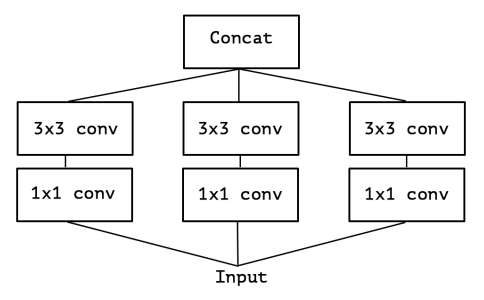

To further simplify, we do not need to use separate 1x1 layers to modify the number of channels in each branch (and mix them together); we can simply use a single 1x1 layer and then split the result into groups for each 3x3 layer.

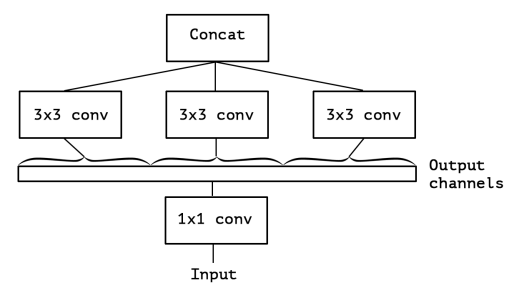

Overall, we get the following grouped (also known as separable) convolution block [[1](#1)].

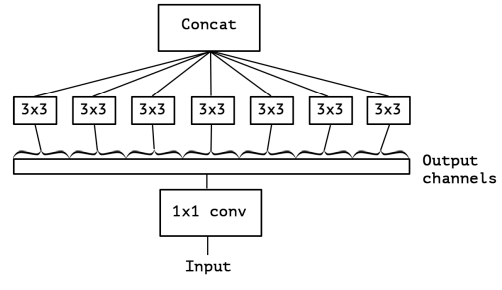

For comparison, the ResNext block, inspired by similar principles, looks as follows [[5](#5)].

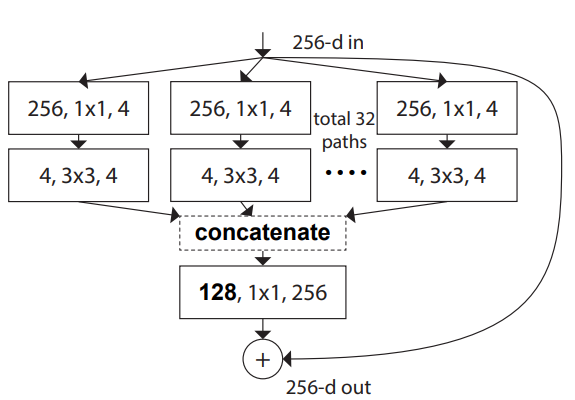

We observe that the ResNext block is a grouped convolutional block with an additional 1x1 convolutional layer. Anyway, let us implement the grouped convolution block. Fortunately, grouped convolution is implemented in PyTorch: we use the usual *nn.LazyConv2d*, we just need to add the argument *groups* (the number of inputs into group convolution must be divisible by the number of groups).

In [6]:
class Separable_convolution(nn.Module):

    def __init__(self, num_channels):
        super().__init__()

        self.net_stack = nn.Sequential(
            nn.LazyConv2d(num_channels, kernel_size=1),
            nn.LazyConv2d(num_channels, kernel_size=3, padding = 1, groups = num_channels)
        )
            

    def forward(self, x):
        output = self.net_stack(x)
        return output

### Xception Architecture <a class="anchor" id="Xception_arch"></a>

The Xception architecture is as follows (all convolution and separable convolution layers are followed by batch normalization) [[1](#1)].

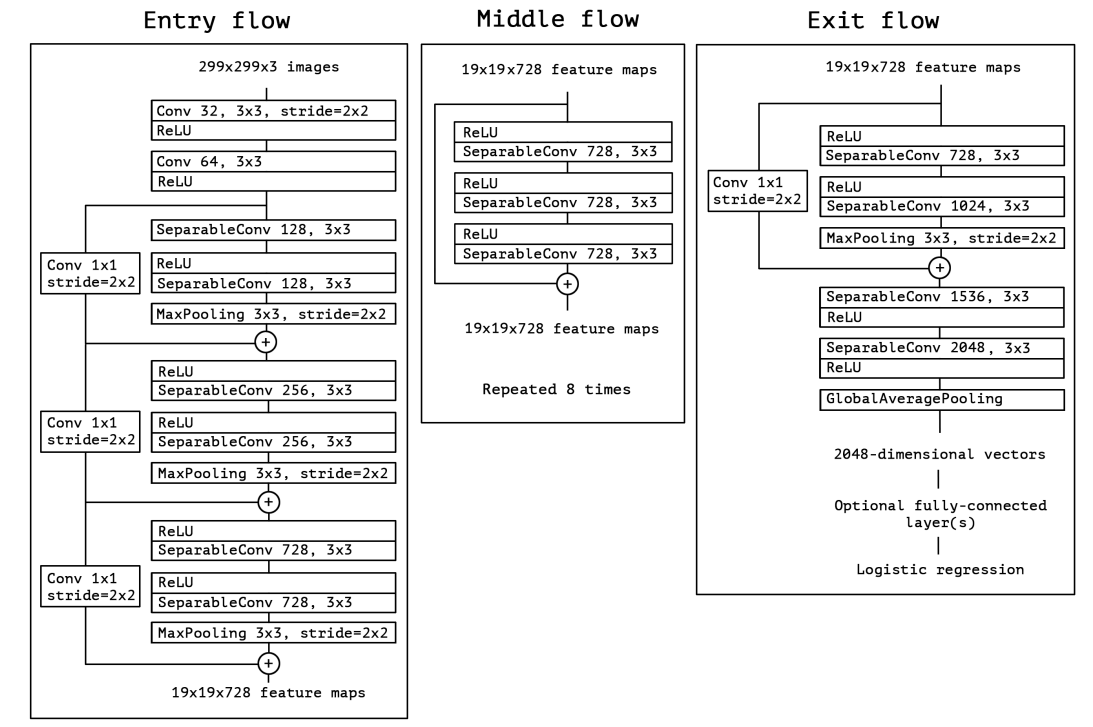

In [7]:
class Xception_entry_flow(nn.Module):
    def __init__(self):
        super().__init__()

        self.entry_1 = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, stride=2, padding=1),  nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.LazyConv2d(64, kernel_size=3, padding=1),  nn.LazyBatchNorm2d(), nn.ReLU()
        )

        self.entry_2 = nn.Sequential(
            Separable_convolution(128),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Separable_convolution(128),  nn.LazyBatchNorm2d(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.downsample_1 = nn.Sequential(nn.LazyConv2d(128, kernel_size = 1, stride = 2), nn.LazyBatchNorm2d())

        self.entry_3 = nn.Sequential(
            nn.ReLU(),
            Separable_convolution(256),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Separable_convolution(256),  nn.LazyBatchNorm2d(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.downsample_2 = nn.Sequential(nn.LazyConv2d(256, kernel_size = 1, stride = 2), nn.LazyBatchNorm2d())

        self.entry_4 = nn.Sequential(
            nn.ReLU(),
            Separable_convolution(728),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Separable_convolution(728),  nn.LazyBatchNorm2d(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.downsample_3 = nn.Sequential(nn.LazyConv2d(728, kernel_size = 1, stride = 2), nn.LazyBatchNorm2d())

    def forward(self, x):

        y1 = self.entry_1(x)
        y2 = self.entry_2(y1) + self.downsample_1(y1)
        y3 = self.entry_3(y2) + self.downsample_2(y2)
        y4 = self.entry_4(y3) + self.downsample_3(y3)
        
        return y4

In [8]:
class Xception_middle_flow_block(nn.Module):
    def __init__(self):
        super().__init__()

        self.middle = nn.Sequential(
            nn.ReLU(),
            Separable_convolution(728),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Separable_convolution(728),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Separable_convolution(728),  nn.LazyBatchNorm2d()
        )

    def forward(self, x):
        y = self.middle(x)
        return y + x

In [9]:
class Xception_exit_flow(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.exit_1 = nn.Sequential(
            nn.ReLU(),
            Separable_convolution(728),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Separable_convolution(1024),  nn.LazyBatchNorm2d(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.downsample_1 = nn.Sequential(nn.LazyConv2d(1024, kernel_size = 1, stride = 2), nn.LazyBatchNorm2d())

        self.exit_2 = nn.Sequential(
            Separable_convolution(1536),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Separable_convolution(2048),  nn.LazyBatchNorm2d(), nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1)), 
            nn.Flatten(),
            nn.LazyLinear(num_classes)
        )

    def forward(self, x):
        y1 = self.exit_1(x) + self.downsample_1(x)
        y2 = self.exit_2(y1) 
        return y2

In [10]:
class Xception(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # entry flow
        self.b1 = Xception_entry_flow()

        # middle flow
        self.b2 = nn.Sequential(
            Xception_middle_flow_block(),
            Xception_middle_flow_block(),
            Xception_middle_flow_block(),
            Xception_middle_flow_block(),
            Xception_middle_flow_block(),
            Xception_middle_flow_block(),
            Xception_middle_flow_block(),
            Xception_middle_flow_block()
        )

        # exit flow
        self.b3 = Xception_exit_flow(10)

        self.net_stack = nn.Sequential(
            self.b1, self.b2, self.b3
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [11]:
layer_summary(Xception(10),(1, 1, 64, 64))

Xception_entry_flow output shape:	 torch.Size([1, 728, 4, 4])
Sequential output shape:	 torch.Size([1, 728, 4, 4])
Xception_exit_flow output shape:	 torch.Size([1, 10])


### Training Xception on Fashion-MNIST and CIFAR-10 <a class="anchor" id="training"></a>

First, let us train Xception on the Fashion-MNIST dataset [[6](#6)].

In [12]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [64, 64], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Resize([64,64]),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# Xception initialization
Xception_cuda = Xception(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
Xception_cuda(x);
Xception_cuda.apply(init_weights_he);

In [13]:
sum(p.numel() for p in Xception_cuda.parameters() if p.requires_grad)

20897018

In [14]:
optim_SGD_cuda =  torch.optim.SGD(Xception_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, Xception_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1854.9878215789795


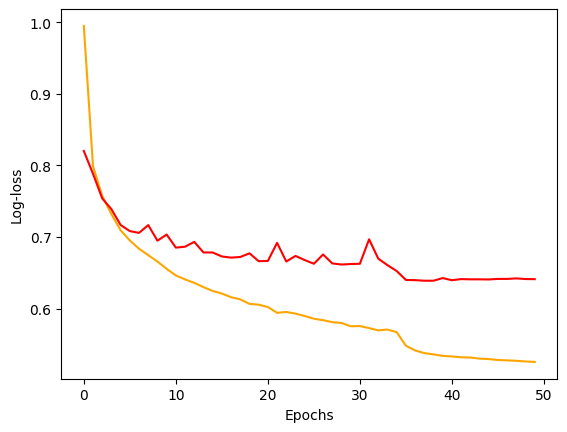

In [15]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

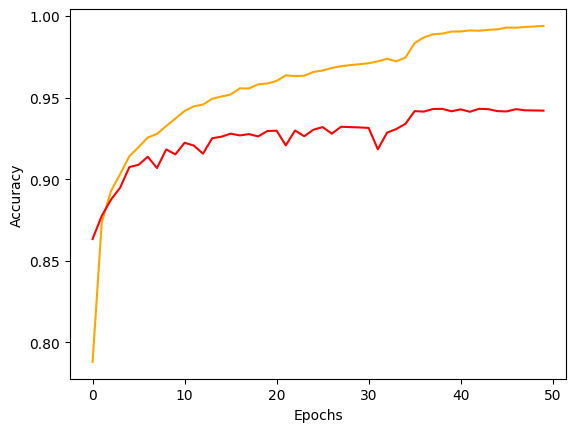

In [16]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

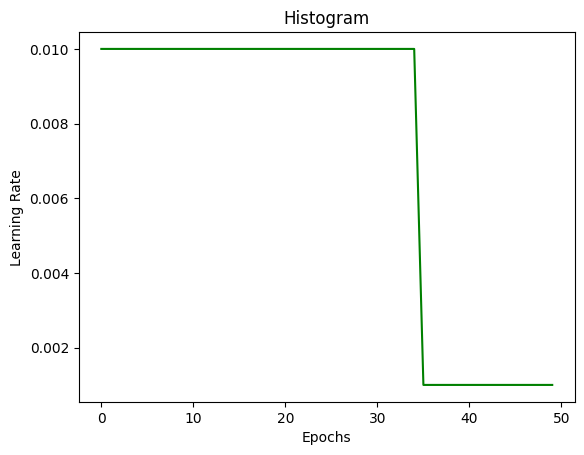

In [17]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [18]:
accu_epochs_train[49]

0.9939333200454712

In [19]:
accu_epochs_test[49]

0.9419999718666077

In [20]:
accu_epochs_test.max()

0.9430999755859375

The test performance over 94% accuracy is pretty good (for example, a bit better than we got from ResNext). As usual, let us modify Xception a bit to make it more usable with original-sized images.

In [21]:
class Xception_entry_flow_mod(nn.Module):
    def __init__(self):
        super().__init__()

        self.entry_1 = nn.Sequential(
            nn.LazyConv2d(32, kernel_size=3, stride=1, padding=1),  nn.LazyBatchNorm2d(), nn.ReLU(), 
            nn.LazyConv2d(64, kernel_size=3, padding=1),  nn.LazyBatchNorm2d(), nn.ReLU()
        )

        self.entry_2 = nn.Sequential(
            Separable_convolution(128),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Separable_convolution(128),  nn.LazyBatchNorm2d(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.downsample_1 = nn.Sequential(nn.LazyConv2d(128, kernel_size = 1, stride = 2), nn.LazyBatchNorm2d())

        self.entry_3 = nn.Sequential(
            nn.ReLU(),
            Separable_convolution(256),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Separable_convolution(256),  nn.LazyBatchNorm2d(), 
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.downsample_2 = nn.Sequential(nn.LazyConv2d(256, kernel_size = 1, stride = 2), nn.LazyBatchNorm2d())

        self.entry_4 = nn.Sequential(
            nn.ReLU(),
            Separable_convolution(728),  nn.LazyBatchNorm2d(), nn.ReLU(),
            Separable_convolution(728),  nn.LazyBatchNorm2d(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )

        self.downsample_3 = nn.Sequential(nn.LazyConv2d(728, kernel_size = 1, stride = 2), nn.LazyBatchNorm2d())

    def forward(self, x):

        y1 = self.entry_1(x)
        y2 = self.entry_2(y1) + self.downsample_1(y1)
        y3 = self.entry_3(y2) + self.downsample_2(y2)
        y4 = self.entry_4(y3) + self.downsample_3(y3)
        
        return y4

In [22]:
class Xception_mod(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # entry flow
        self.b1 = Xception_entry_flow_mod()

        # middle flow
        self.b2 = nn.Sequential(
            Xception_middle_flow_block(),
            Xception_middle_flow_block(),
            Xception_middle_flow_block(),
            Xception_middle_flow_block()
        )

        # exit flow
        self.b3 = Xception_exit_flow(10)

        self.net_stack = nn.Sequential(
            self.b1, self.b2, self.b3
        )

    def forward(self, x):
        output = self.net_stack(x)
        return output

In [23]:
layer_summary(Xception_mod(10),(1, 1, 28, 28))

Xception_entry_flow_mod output shape:	 torch.Size([1, 728, 4, 4])
Sequential output shape:	 torch.Size([1, 728, 4, 4])
Xception_exit_flow output shape:	 torch.Size([1, 10])


In [24]:
torch.manual_seed(123)

# data loader
transforms_fashion_mnist_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size = [28, 28], scale = [0.9,1.1]) 
    ]
)

transforms_fashion_mnist_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(0.5, 0.5)]
)

fashion_mnist_train = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_fashion_mnist_train)
fashion_mnist_test = torchvision.datasets.FashionMNIST(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_fashion_mnist_test)

fashion_mnist_train_loader = DataLoader(dataset = fashion_mnist_train, batch_size = 250, shuffle = True) 
fashion_mnist_test_loader = DataLoader(dataset = fashion_mnist_test, batch_size = 250, shuffle = False)  


# Xception initialization
Xception_cuda = Xception_mod(10).to(cuda_device)

x = (fashion_mnist_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
Xception_cuda(x);
Xception_cuda.apply(init_weights_he);

In [25]:
optim_SGD_cuda =  torch.optim.SGD(Xception_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[35], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 50

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]   = train_test_loop_cuda(fashion_mnist_train_loader, fashion_mnist_test_loader, Xception_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

1603.6948411464691


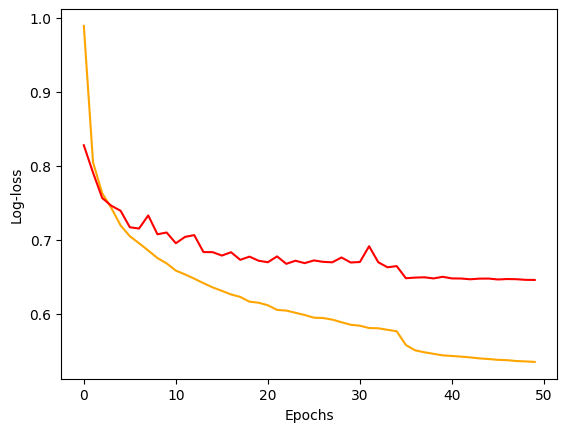

In [26]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

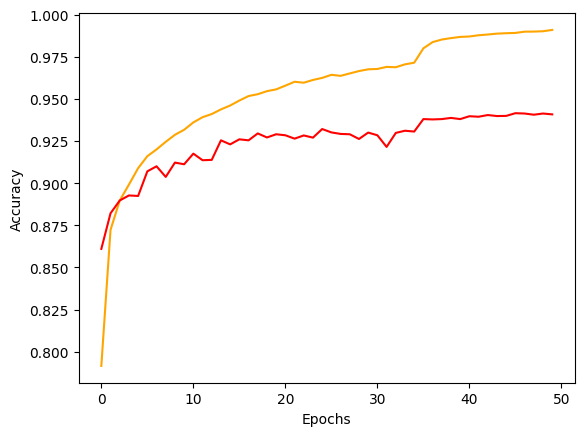

In [27]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

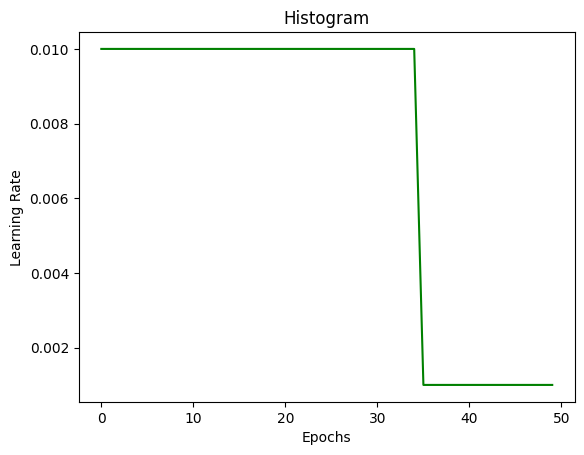

In [28]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [29]:
accu_epochs_train[49]

0.9909000396728516

In [30]:
accu_epochs_test[49]

0.9407999515533447

In [31]:
accu_epochs_test.max()

0.9414999485015869

The test set accuracy is mostly the same. Let us move to the CIFAR-10 dataset (https://www.cs.toronto.edu/~kriz/cifar.html). We will use our smaller model right away.

In [32]:
torch.manual_seed(123)

transforms_cifar10_train =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616]),
    torchvision.transforms.RandomHorizontalFlip(),
    torchvision.transforms.RandomResizedCrop(size=[32,32], scale = [0.8, 1.4]),
    ]
)

transforms_cifar10_test =  torchvision.transforms.Compose(
    [torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2470, 0.2435, 0.2616])]
)

cifar10_train = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = True,  download = True, transform = transforms_cifar10_train)
cifar10_test = torchvision.datasets.CIFAR10(root = 'D:/nine circles 2', train = False,  download = True, transform = transforms_cifar10_test)


cifar10_train_loader = DataLoader(dataset = cifar10_train, batch_size = 125, shuffle = True) 
cifar10_test_loader = DataLoader(dataset = cifar10_test, batch_size = 125, shuffle = False)

# Xception initialization
Xception_cuda = Xception_mod(10).to(cuda_device)

x = (cifar10_train.__getitem__(0)[0]).to(cuda_device)
x = x[None,:,:,:]
Xception_cuda(x);
Xception_cuda.apply(init_weights_he);

In [33]:
optim_SGD_cuda =  torch.optim.SGD(Xception_cuda.parameters(), lr = 0.01, momentum = 0.9, weight_decay = 0.001)
scheduler_cuda = torch.optim.lr_scheduler.MultiStepLR(optim_SGD_cuda, milestones=[60, 85], gamma = 0.1)
cross_entropy_loss = nn.CrossEntropyLoss(label_smoothing=0.1)

n_epochs = 100

loss_epochs_train = np.zeros(n_epochs) 
loss_epochs_test = np.zeros(n_epochs) 
accu_epochs_train = np.zeros(n_epochs) 
accu_epochs_test = np.zeros(n_epochs) 

learning_rates = np.zeros(n_epochs)

start = time.time()
for t in range(n_epochs):
    loss_epochs_train[t], loss_epochs_test[t], learning_rates[t], accu_epochs_train[t], accu_epochs_test[t]  = train_test_loop_cuda(cifar10_train_loader, cifar10_test_loader, Xception_cuda, cross_entropy_loss, optim_SGD_cuda, scheduler_cuda)
end = time.time()
print(end - start)

3337.5962069034576


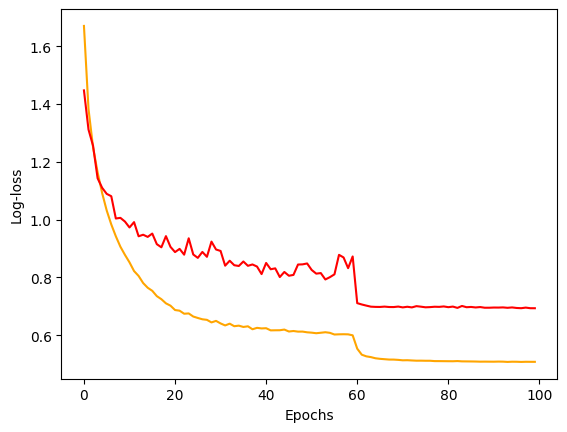

In [34]:
plt.plot(loss_epochs_train, color = 'orange')
plt.plot(loss_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Log-loss');

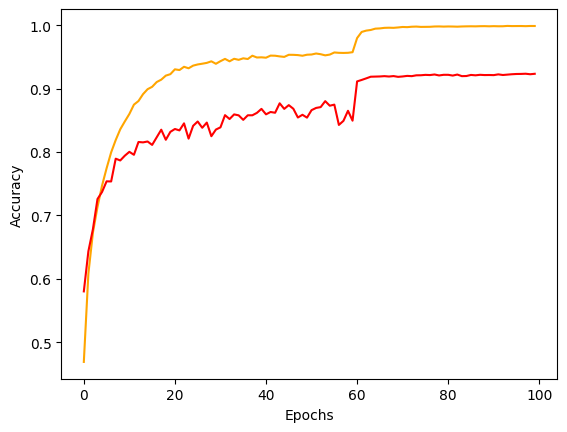

In [35]:
plt.plot(accu_epochs_train, color = 'orange')
plt.plot(accu_epochs_test, color = 'red')
plt.xlabel('Epochs')
plt.ylabel('Accuracy');

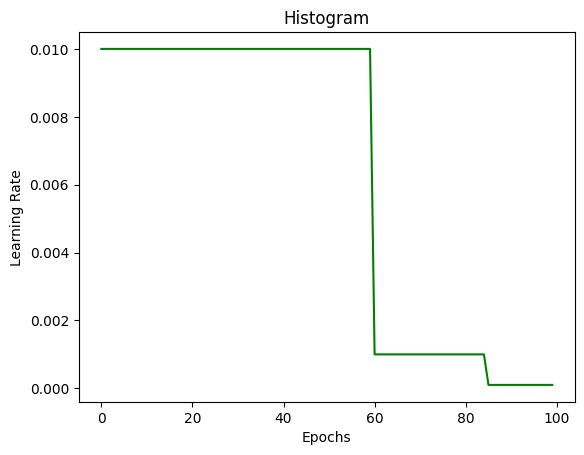

In [36]:
plt.plot(learning_rates, color = 'green')
plt.title('Histogram')
plt.xlabel('Epochs')
plt.ylabel('Learning Rate');

In [37]:
accu_epochs_train[99]

0.9986400008201599

In [38]:
accu_epochs_test[99]

0.9232999682426453

In [39]:
accu_epochs_test.max()

0.9233999848365784

The performance is decent, but we managed to do better (e.g., 94% with ResNet and ResNext, over 94.5% with DenseNet). Again, we should mention that Xception was primarily designed for the ImageNet dataset [[1](#1)], and unlike ResNext [[5](#5)] or DenseNet [[7](#7)], there are no experiments of custom Xception architectures on CIFAR-10 (or CIFAR-100) in the original paper [[1](#1)].

## References <a class="anchor" id="references"></a>

<a id="1">[1]</a> FRAN, Chollet, et al. Xception: Deep Learning with Depthwise Separable Convolutions. In: *IEEE conference on computer vision and pattern recognition (CVPR)*. 2017.

<a id="2">[2]</a> SZEGEDY, Christian, et al. Going deeper with convolutions. In: *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2015. p. 1-9.

<a id="3">[3]</a> SZEGEDY, Christian, et al. Rethinking the inception architecture for computer vision. In: *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2016. p. 2818-2826.

<a id="4">[4]</a> SZEGEDY, Christian, et al. Inception-v4, inception-resnet and the impact of residual connections on learning. In: *Proceedings of the AAAI conference on artificial intelligence.* 2017.

<a id="5">[5]</a> XIE, Saining, et al. Aggregated residual transformations for deep neural networks. In: *Proceedings of the IEEE conference on computer vision and pattern recognition*. 2017. p. 1492-1500.

<a id="6">[6]</a> XIAO, Han; RASUL, Kashif; VOLLGRAF, Roland. Fashion-mnist: a novel image dataset for benchmarking machine learning algorithms. arXiv preprint arXiv:1708.07747, 2017.

<a id="7">[7]</a> HUANG, Gao, et al. Densely connected convolutional networks. In: *Proceedings of the IEEE conference on computer vision and pattern recognition.* 2017. p. 4700-4708.